# Day 12: Demo Day And Research Artifact

Assemble a final benchmark artifact: trajectory, evaluation, replay verification, mechanism explanation, and combined capstone score.

In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks" / "tutorials"))

tu = importlib.import_module("tutorial_utils")

pd.set_option("display.precision", 4)
OUTPUT_DIR = tu.ensure_output(12)
print("project root:", ROOT)
print("output dir:", OUTPUT_DIR)


project root: D:\Projects\ChemWorld
output dir: D:\Projects\ChemWorld\runs\tutorials\day12


In [2]:
tu.display_learning_goal(
    12,
    "Demo Day artifact",
    [
        "Load a final trajectory artifact.",
        "Score performance and mechanism explanation separately.",
        "Check reproducibility through replay verification.",
        "Create a compact presentation-ready summary.",
    ],
)

In [3]:
tu.display_api_card()

In [4]:
tu.display_student_checkpoint(
    12,
    [
        "one final artifact JSON",
        "one mechanism score",
        "one combined capstone score",
        "one demo-day slide summary",
    ],
)

In [5]:
from chemworld.data.logging import load_jsonl
from chemworld.eval.explanations import combined_artifact_score, score_mechanism_explanation
from chemworld.eval.metrics import evaluate_records
from chemworld.eval.verify import verify_records

source = ROOT / "runs" / "tutorials" / "day07" / "best_candidate_capstone.jsonl"
if not source.exists():
    fallback_recipe = {
        "temperature": 75.0,
        "time": 0.50,
        "initial_concentration": 0.35,
        "stirring_speed": 650.0,
        "catalyst": 1,
        "solvent": 1,
    }
    records = tu.write_recipe_trajectory(
        fallback_recipe,
        source,
        split="public-test",
        seed=77,
        agent_name="demo_day_fallback",
    )
else:
    records = load_jsonl(source)

evaluation = evaluate_records(records).to_dict()
verification = verify_records(records).to_dict()
tu.show_json_panel("Evaluation", evaluation)
tu.show_json_panel("Verification", verification)


In [6]:
explanation = {
    "hypothesis": (
        "Moderate temperature improves conversion while avoiding "
        "high-temperature degradation."
    ),
    "learned_mechanism": (
        "Yield is limited by degradation, byproduct formation, and "
        "catalyst-solvent interactions that affect selectivity."
    ),
    "safety": (
        "Higher concentration and hotter operation increase risk, so a lower-risk "
        "solvent and moderate loading are preferred."
    ),
    "limitations": (
        "The result is seed-limited and uncertain; public-test success may not "
        "generalize to private-eval."
    ),
    "next_experiment": (
        "Run a local validation design around the selected recipe with one "
        "UV-vis mid-run measurement."
    ),
}
mechanism = score_mechanism_explanation(explanation).to_dict()
tu.show_json_panel("Mechanism explanation", explanation)
tu.show_json_panel("Rubric score", mechanism)


In [7]:
import json

is_reproducible = bool(verification.get("verified", verification.get("ok", False)))
artifact_score = combined_artifact_score(
    performance=float(evaluation["total_score"]),
    mechanism_score=float(mechanism["normalized"]),
    reproducibility=1.0 if is_reproducible else 0.0,
)
summary = {
    "artifact_score": artifact_score,
    "evaluation_total_score": evaluation["total_score"],
    "mechanism_score": mechanism["normalized"],
    "reproducible": is_reproducible,
    "best_score": evaluation["final_best_score"],
    "safety_aware_score": evaluation["safety_aware_score"],
    "required_next_step": (
        "Run the strategy over public-test and private-eval with at least 30 seeds "
        "before making benchmark claims."
    ),
}
summary_path = OUTPUT_DIR / "demo_day_summary.json"
summary_path.write_text(
    json.dumps(summary, indent=2, sort_keys=True) + "\n",
    encoding="utf-8",
)
tu.show_json_panel("Demo Day summary artifact", summary)
print(f"Wrote {summary_path.relative_to(ROOT)}")


Wrote runs\tutorials\day12\demo_day_summary.json


,dimension,value
0,performance,0.3932
1,mechanism,0.8571
2,reproducibility,1.0000
3,combined,0.6538


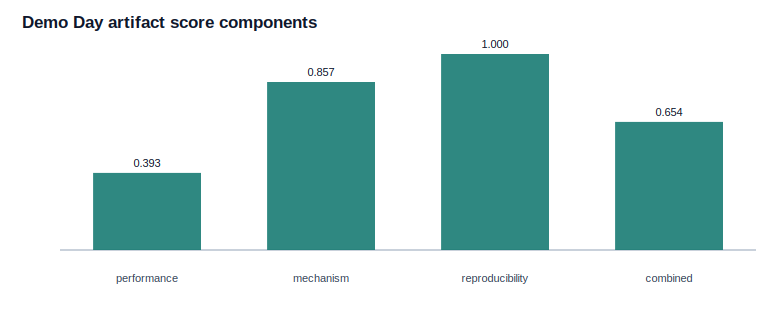

In [8]:
presentation_df = pd.DataFrame(
    [
        {"dimension": "performance", "value": evaluation["total_score"]},
        {"dimension": "mechanism", "value": mechanism["normalized"]},
        {"dimension": "reproducibility", "value": 1.0 if is_reproducible else 0.0},
        {"dimension": "combined", "value": artifact_score},
    ]
)
display(presentation_df)
display(
    tu.bar_svg(
        presentation_df["dimension"].tolist(),
        presentation_df["value"].astype(float).tolist(),
        title="Demo Day artifact score components",
        color="#0f766e",
    )
)
